# 🧠 Pancreatic Cancer Biomarker Risk Predictor: ML Training Pipeline

## 1. Data Ingestion & Exploratory Data Analysis (EDA)

In [3]:

from google.colab import files
uploaded = files.upload()

Saving pancreas_data.csv to pancreas_data (1).csv


In [4]:
import pandas as pd

data = pd.read_csv("pancreas_data.csv")
data.head()

,Age,Gender,CA19-9,Lipase,Amylase,Glucose,Bilirubin,ALT,AST,WBC,Risk
0,45,1,25,120,80,95,0.8,30,28,7000,Low
1,52,0,40,150,110,105,1.0,35,30,7500,Low
2,60,1,90,220,170,160,2.1,80,75,11000,High
3,38,0,15,90,60,85,0.6,25,20,6500,Low
4,67,1,120,260,180,180,2.5,95,88,13000,High


In [5]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        100 non-null    int64  
 1   Gender     100 non-null    int64  
 2   CA19-9     100 non-null    int64  
 3   Lipase     100 non-null    int64  
 4   Amylase    100 non-null    int64  
 5   Glucose    100 non-null    int64  
 6   Bilirubin  100 non-null    float64
 7   ALT        100 non-null    int64  
 8   AST        100 non-null    int64  
 9   WBC        100 non-null    int64  
 10  Risk       100 non-null    object 
dtypes: float64(1), int64(9), object(1)
memory usage: 8.7+ KB


,Age,Gender,CA19-9,Lipase,Amylase,Glucose,Bilirubin,ALT,AST,WBC
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,51.600000,0.500000,67.500000,166.000000,117.500000,129.000000,1.46000,53.300000,48.600000,9130.000000
std,12.269697,0.502519,55.924281,70.524729,47.739296,38.257501,0.80929,30.000168,28.037493,2843.049295
min,29.000000,0.000000,10.000000,70.000000,50.000000,85.000000,0.50000,20.000000,18.000000,6000.000000
25%,45.000000,0.000000,25.000000,120.000000,80.000000,95.000000,0.80000,30.000000,28.000000,7000.000000
50%,51.000000,0.500000,47.500000,145.000000,105.000000,115.000000,1.15000,39.000000,36.000000,7900.000000
75%,60.000000,1.000000,90.000000,220.000000,170.000000,160.000000,2.10000,80.000000,75.000000,11000.000000
max,72.000000,1.000000,200.000000,300.000000,190.000000,200.000000,3.00000,110.000000,100.000000,15000.000000


In [6]:
mapping = {"Low": 0, "Medium": 1, "High": 2}
data["Risk"] = data["Risk"].map(mapping)

In [7]:
X = data.drop("Risk", axis=1)
y = data["Risk"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 2. Model Training & Optimization

In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

## 3. Performance Evaluation & Weights Serialization

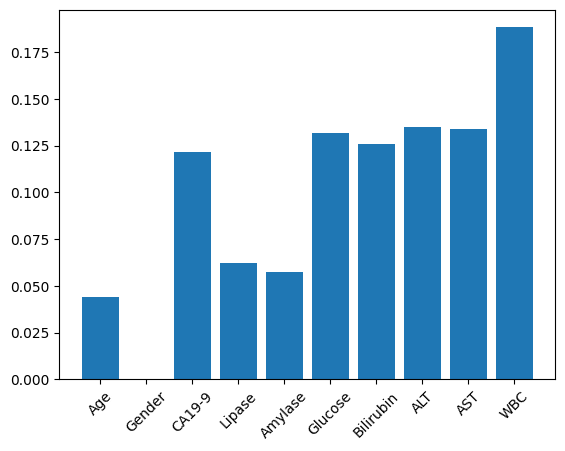

In [11]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.bar(X.columns, importance)
plt.xticks(rotation=45)
plt.show()

In [12]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

In [13]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>